# Breast Cancer Gene Expression Predictor on GSE61304

by mikeph_

Loaded model, selector, scaler, and train_genes.
External expression shape: (62, 54675)
Selected diagnosis row index: 1
External labels (0=Normal, 1=Cancer): [ 4 58]
Common genes: 200
External ROC-AUC: 0.8793103448275862
              precision    recall  f1-score   support

           0       0.06      1.00      0.12         4
           1       0.00      0.00      0.00        58

    accuracy                           0.06        62
   macro avg       0.03      0.50      0.06        62
weighted avg       0.00      0.06      0.01        62



/Users/mikeph/miniconda3/envs/geo_ml/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/mikeph/miniconda3/envs/geo_ml/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/mikeph/miniconda3/envs/geo_ml/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/mikeph/miniconda3/envs/geo_ml/lib/python3.14/site-packages/sklearn/metrics/_classification.py:18

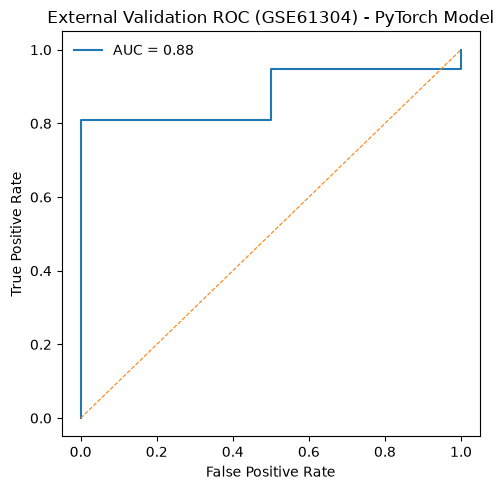

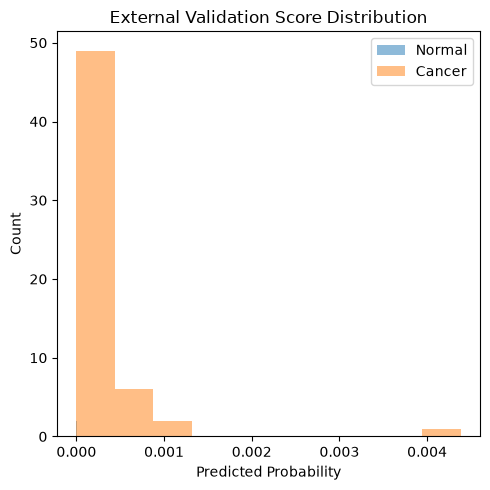

In [6]:
import pandas as pd
import numpy as np
import torch
from torch import nn
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, classification_report, roc_curve, auc
from sklearn.decomposition import PCA

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

# Model class must match training exactly
class LogisticRegression(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x)

# --- Load saved artifacts ---
selector = joblib.load("models/torch/training_selector.joblib")
scaler = joblib.load("models/torch/training_scaler.joblib")
train_genes = joblib.load("models/torch/train_genes.joblib")

model = LogisticRegression(input_dim=len(train_genes)).to(device)
model.load_state_dict(torch.load("models/torch/training_model.pt", map_location=device))
model.eval()

print("Loaded model, selector, scaler, and train_genes.")

# --- Load external dataset (GSE61304) ---
ext_csv = "data/GSE61304_series_matrix.txt"

expr_ext = pd.read_csv(ext_csv, sep="\t", comment="!", index_col=0)
X_ext = expr_ext.T.apply(pd.to_numeric, errors="coerce")
X_ext = X_ext.fillna(X_ext.mean())

print("External expression shape:", X_ext.shape)

# --- Extract true diagnosis labels ---
characteristics = []
with open(ext_csv) as f:
    for line in f:
        if line.startswith("!Sample_characteristics_ch1"):
            values = [v.strip().strip('"') for v in line.strip().split("\t")[1:]]
            characteristics.append(values)

characteristics = np.array(characteristics)

diagnosis_row = None
for i, row in enumerate(characteristics):
    matches = [
        v.lower().startswith("diagnosis:")
        and not v.lower().startswith("diagnosis: age")
        and not v.lower().startswith("age at diagnosis:")
        for v in row
    ]
    if sum(matches) > len(row) * 0.5:
        diagnosis_row = row
        print("Selected diagnosis row index:", i)
        break

if diagnosis_row is None:
    raise RuntimeError("True diagnosis row not found in GEO file.")

y_ext = np.array([
    0 if "within normal limits" in v.lower() else 1
    for v in diagnosis_row
])

print("External labels (0=Normal, 1=Cancer):", np.bincount(y_ext))
assert len(np.unique(y_ext)) == 2, "Only one class found in external labels!"

# --- Match genes to training selection ---
common_genes = train_genes.intersection(X_ext.columns)
print("Common genes:", len(common_genes))
assert len(common_genes) == len(train_genes), "Missing genes in external dataset"

X_ext_common = X_ext[train_genes]

# --- Scale using the TRAINING-fitted scaler (never refit here) ---
X_ext_scaled = scaler.transform(X_ext_common)

# --- Convert to tensors ---
X_ext_t = torch.tensor(X_ext_scaled, dtype=torch.float32).to(device)
y_ext_t = torch.tensor(y_ext, dtype=torch.float32).view(-1, 1).to(device)

# --- Predict ---
with torch.no_grad():
    ext_logits = model(X_ext_t)
    ext_prob = torch.sigmoid(ext_logits)
    ext_pred = (ext_prob >= 0.5).float()

ext_prob_np = ext_prob.cpu().numpy().flatten()
ext_pred_np = ext_pred.cpu().numpy().flatten()

print("External ROC-AUC:", roc_auc_score(y_ext, ext_prob_np))
print(classification_report(y_ext, ext_pred_np))

# --- ROC curve ---
fpr, tpr, _ = roc_curve(y_ext, ext_prob_np)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_val:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=0.8)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("External Validation ROC (GSE61304) - PyTorch Model")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig("output/roc_curve_external_torch.pdf")
plt.show()

# --- Score distribution ---
plt.figure(figsize=(5, 5))
plt.hist(ext_prob_np[y_ext == 0], alpha=0.5, label="Normal")
plt.hist(ext_prob_np[y_ext == 1], alpha=0.5, label="Cancer")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.legend()
plt.title("External Validation Score Distribution")
plt.tight_layout()
plt.savefig("output/score_distribution_external.pdf")
plt.show()

/Users/mikeph/miniconda3/envs/geo_ml/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


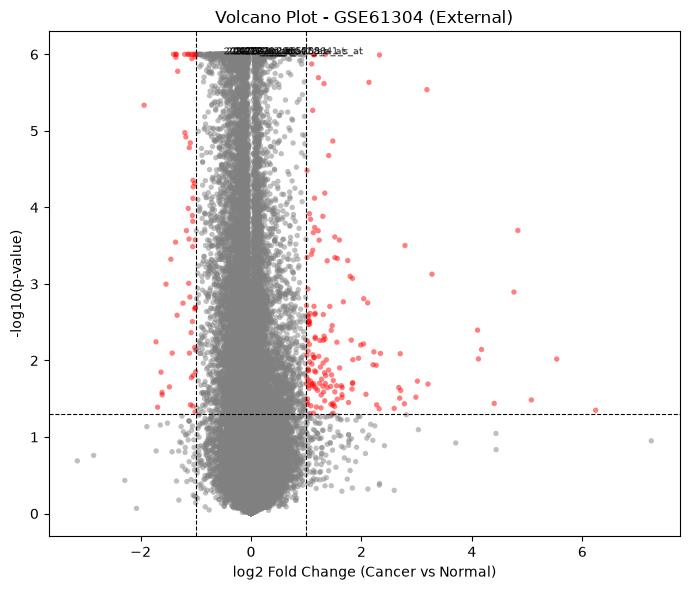

In [7]:
from scipy import stats

def volcano_plot(X_data, y_data, title="Volcano Plot", top_n_labels=10, save_path=None):
    """
    X_data: samples x genes DataFrame (e.g. X or X_ext)
    y_data: array of 0/1 labels (0=Normal, 1=Cancer)
    """
    cancer = X_data[y_data == 1]
    normal = X_data[y_data == 0]

    # Log2 fold change (mean cancer vs mean normal)
    # small epsilon avoids log(0) issues if any values are exactly 0
    eps = 1e-6
    log2fc = np.log2((cancer.mean(axis=0) + eps) / (normal.mean(axis=0) + eps))

    # t-test per gene
    t_stat, p_val = stats.ttest_ind(cancer, normal, axis=0, equal_var=False)
    p_val = np.nan_to_num(p_val, nan=1.0)  # guard against NaNs from zero-variance genes
    neg_log_p = -np.log10(p_val + eps)

    volcano_df = pd.DataFrame({
        "Gene": X_data.columns,
        "log2FC": log2fc,
        "neg_log10_p": neg_log_p,
        "p_val": p_val
    })

    # Significance thresholds (typical defaults — adjust if you have domain reasons to)
    fc_thresh = 1.0     # |log2FC| > 1 means 2-fold change
    p_thresh = 0.05

    colors = np.where(
        (volcano_df["p_val"] < p_thresh) & (volcano_df["log2FC"].abs() > fc_thresh),
        "red",
        "gray"
    )

    plt.figure(figsize=(7, 6))
    plt.scatter(volcano_df["log2FC"], volcano_df["neg_log10_p"], c=colors, alpha=0.5, s=15, edgecolor="none")

    plt.axhline(-np.log10(p_thresh), linestyle="--", color="black", linewidth=0.8)
    plt.axvline(fc_thresh, linestyle="--", color="black", linewidth=0.8)
    plt.axvline(-fc_thresh, linestyle="--", color="black", linewidth=0.8)

    # Label top N most significant genes
    top_genes = volcano_df.nsmallest(top_n_labels, "p_val")
    for _, row in top_genes.iterrows():
        plt.annotate(row["Gene"], (row["log2FC"], row["neg_log10_p"]), fontsize=7, alpha=0.8)

    plt.xlabel("log2 Fold Change (Cancer vs Normal)")
    plt.ylabel("-log10(p-value)")
    plt.title(title)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path)
    plt.show()

    return volcano_df

volcano_df_ext = volcano_plot(X_ext, y_ext, title="Volcano Plot - GSE61304 (External)", save_path="docs/results_photos_torch/volcano_ext.png")